# Plotting Umaps Similar to Fig 2 a,b,e

In [1]:

# import packages
import scanpy as sc
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# also requires igraph and leidenalg

In [11]:
# load in adata
control_path = "../../../results/control/integrated_results/concatenated/pbmc_2_batch_base_balanced_1_celltypes_0_downsample_0_batch_ds_c_14_integrated_concat.h5ad"
hier_path = "../../../results/control/integrated_results/concatenated/pbmc_2_batch_hierarchical_balanced_1_celltypes_0_downsample_0_batch_ds_c_14_integrated_concat.h5ad"
# new - transcriptformer
tsf_path = "../../../results/transcriptformer/pbmc_2_batch_1_celltypes_0.1_downsample_0_batch_ds_c_0_integrated_helical_p1.h5ad"
# new - finetuned scgpt
scvi_scgpt_out_path = "../../../results/finetuning/scvi_scgpt_output.h5ad"
scvi_scgpt_emb_path = "../../../results/finetuning/scvi_scgpt_emb.h5ad"
harmony_scgpt_out_path = "../../../results/finetuning/harmony_scgpt_output.h5ad"
harmony_scgpt_emb_path = "../../../results/finetuning/harmony_scgpt_emb.h5ad"

control = sc.read_h5ad(control_path)
hier = sc.read_h5ad(hier_path)
# new - transcriptformer
tsf = sc.read_h5ad(tsf_path)
# new - finetuned scgpt
scvi_scgpt_out = sc.read_h5ad(scvi_scgpt_out_path)
scvi_scgpt_emb = sc.read_h5ad(scvi_scgpt_emb_path)
harmony_scgpt_out = sc.read_h5ad(harmony_scgpt_out_path)
harmony_scgpt_emb = sc.read_h5ad(harmony_scgpt_emb_path)

# separate adata by integration method
integration_method = control.obs["integration_method"].values
adata_c_uce = control[integration_method == "uce"]
adata_c_scgpt = control[integration_method == "scgpt"]
adata_c_geneformer = control[integration_method == "geneformer"]
adata_c_harmony = control[integration_method == "harmony"]
adata_c_scvi = control[integration_method == "scvi"]

integration_method = hier.obs["integration_method"].values
adata_h_uce = hier[integration_method == "uce"]
adata_h_scgpt = hier[integration_method == "scgpt"]
adata_h_geneformer = hier[integration_method == "geneformer"]
adata_h_harmony = hier[integration_method == "harmony"]
adata_h_scvi = hier[integration_method == "scvi"]

integration_method_tsf = tsf.obs["integration_method"].values
adata_tsf = tsf[integration_method_tsf == "transcriptformer"]

# adding in method
scvi_scgpt_out.obs["integration_method"] = "scvi_scgpt_out"
scvi_scgpt_emb.obs["integration_method"] = "scvi_scgpt_emb"
harmony_scgpt_out.obs["integration_method"] = "harmony_scgpt_out"
harmony_scgpt_emb.obs["integration_method"] = "harmony_scgpt_emb"

# adding in method
scvi_scgpt_out.obs["integration_method"] = "scvi_scgpt_out"
scvi_scgpt_emb.obs["integration_method"] = "scvi_scgpt_emb"
harmony_scgpt_out.obs["integration_method"] = "harmony_scgpt_out"
harmony_scgpt_emb.obs["integration_method"] = "harmony_scgpt_emb"

/opt/anaconda3/envs/iniq_analysis/lib/python3.13/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/envs/iniq_analysis/lib/python3.13/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/envs/iniq_analysis/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


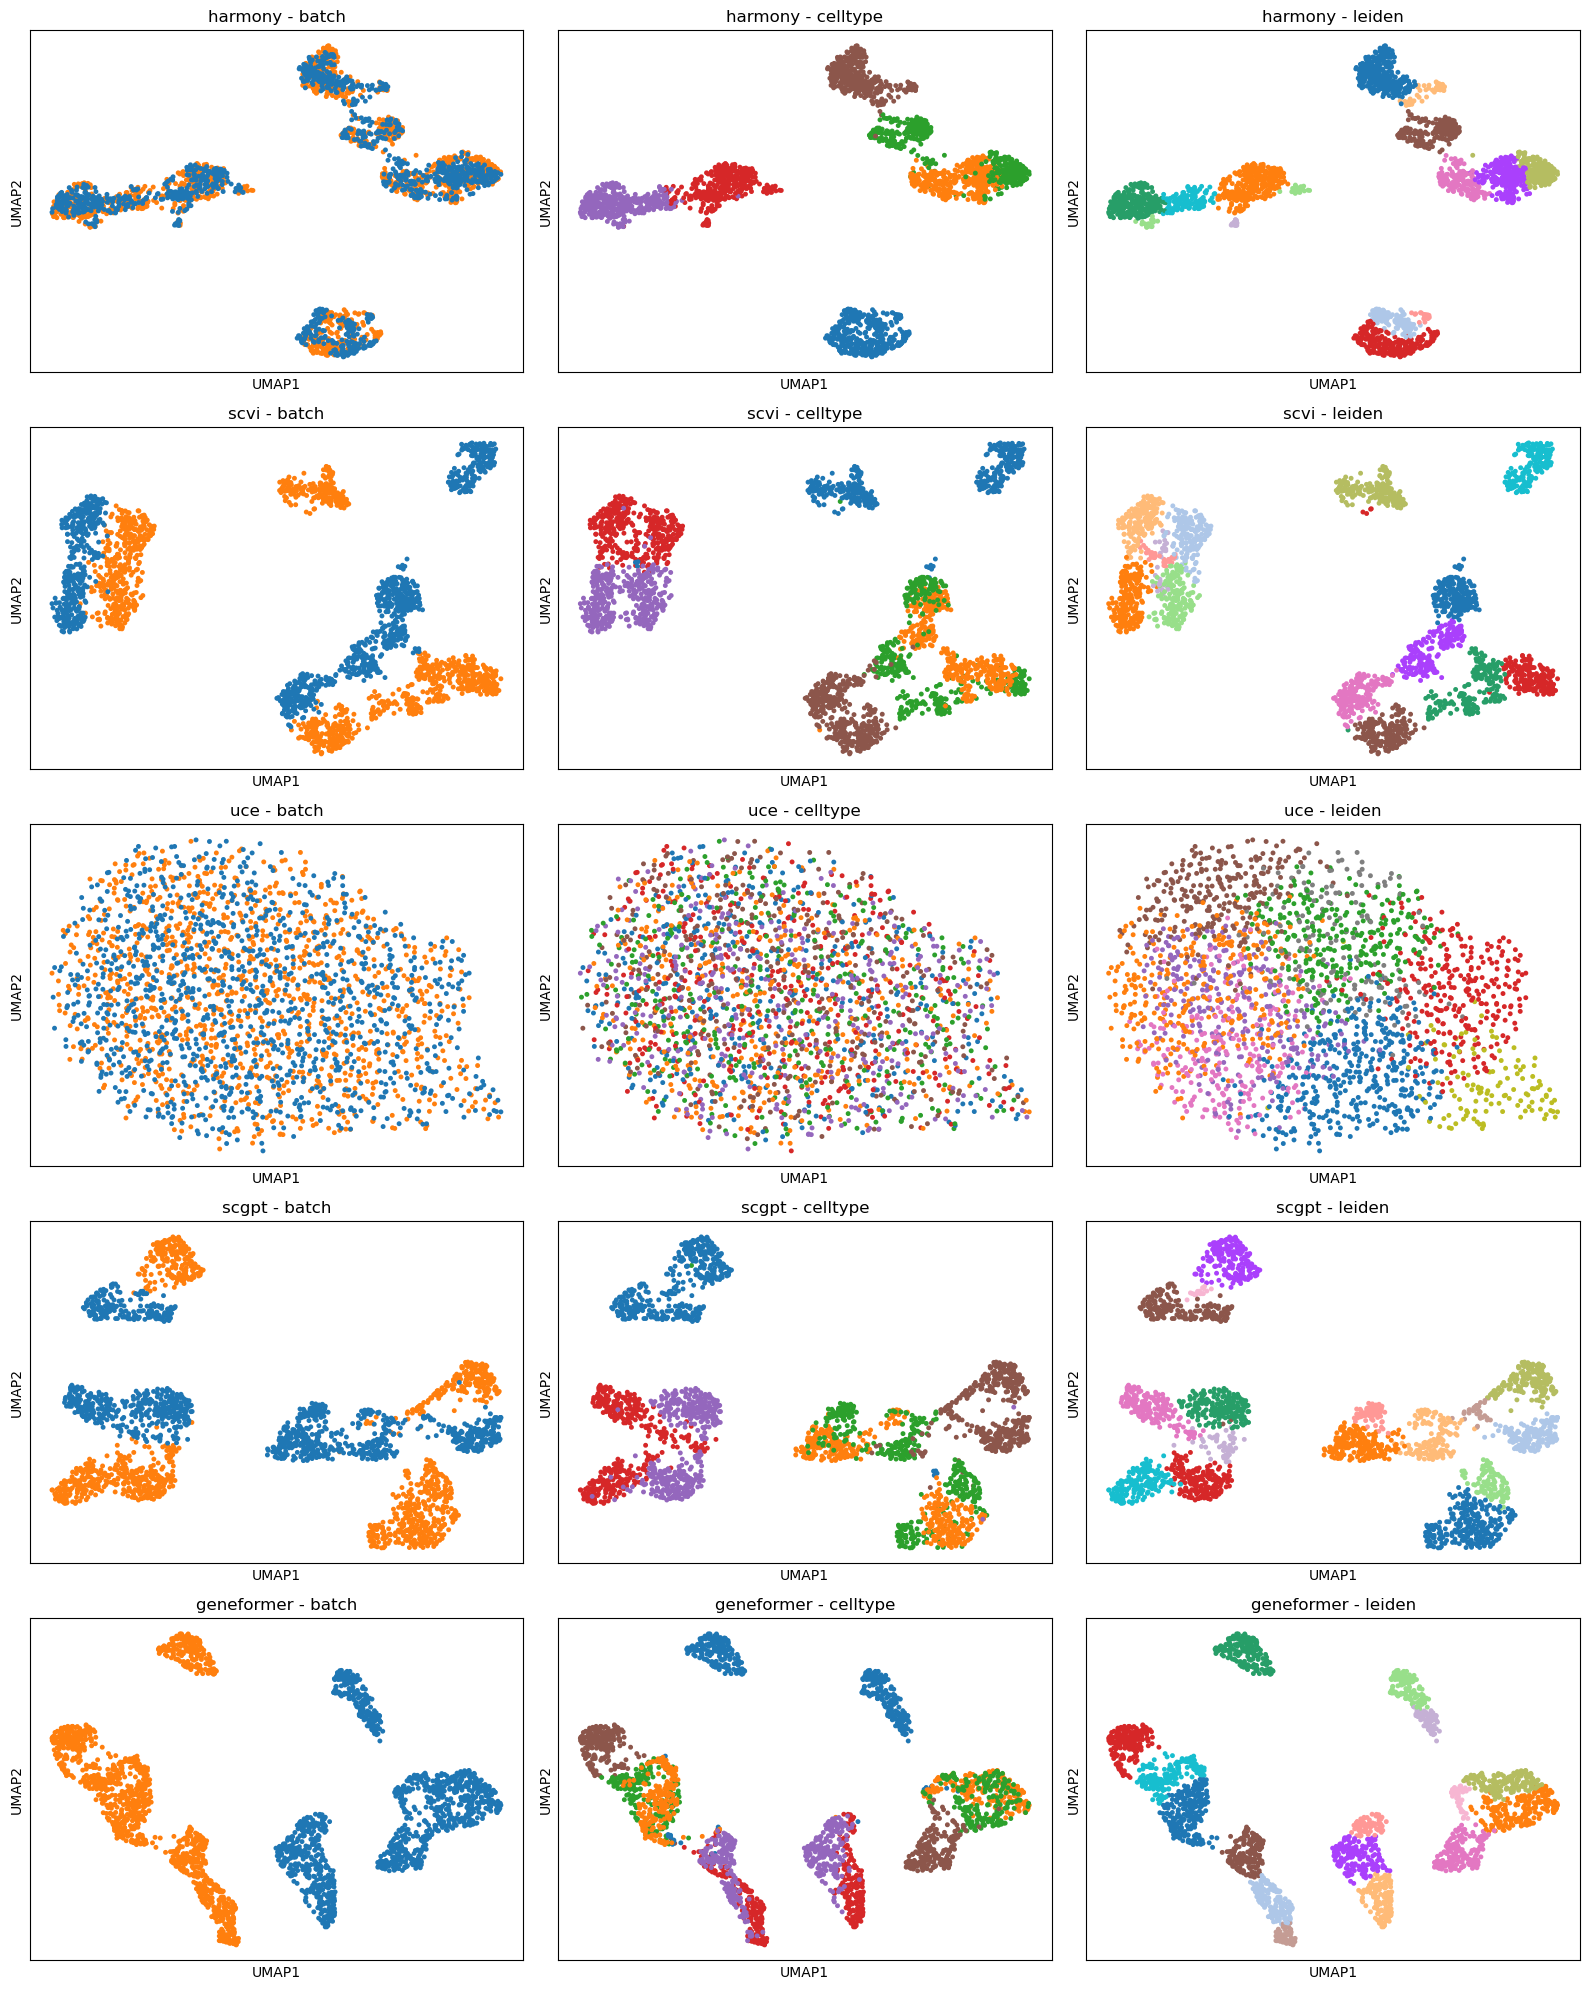

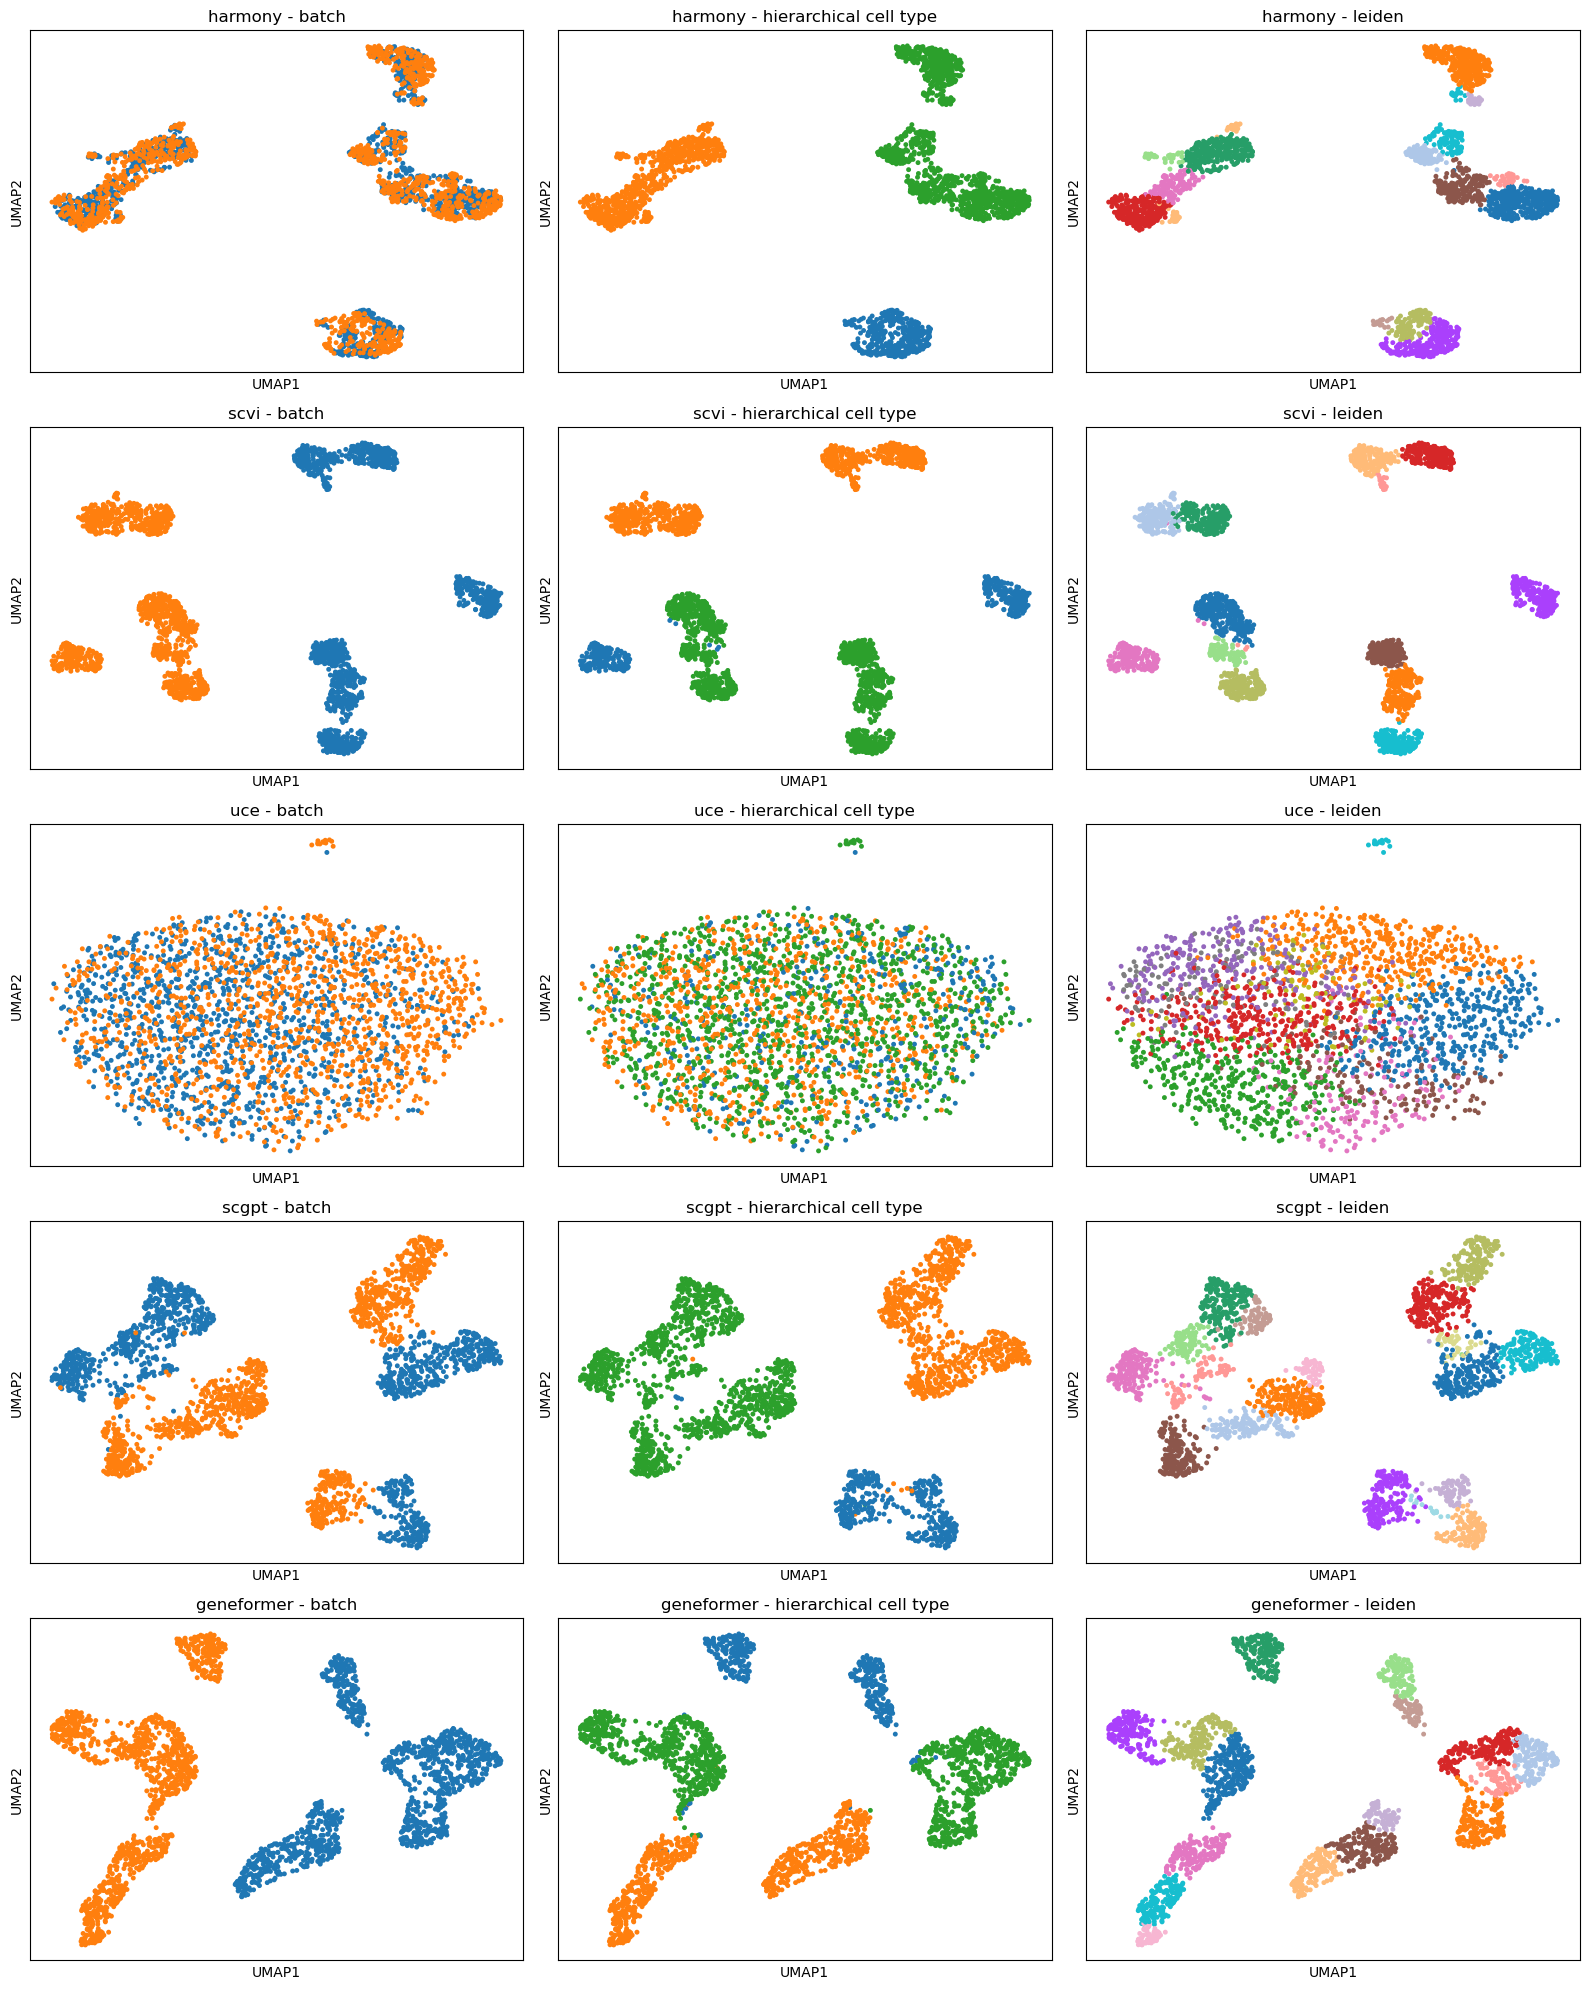

IndexError: index 12 is out of bounds for axis 0 with size 3

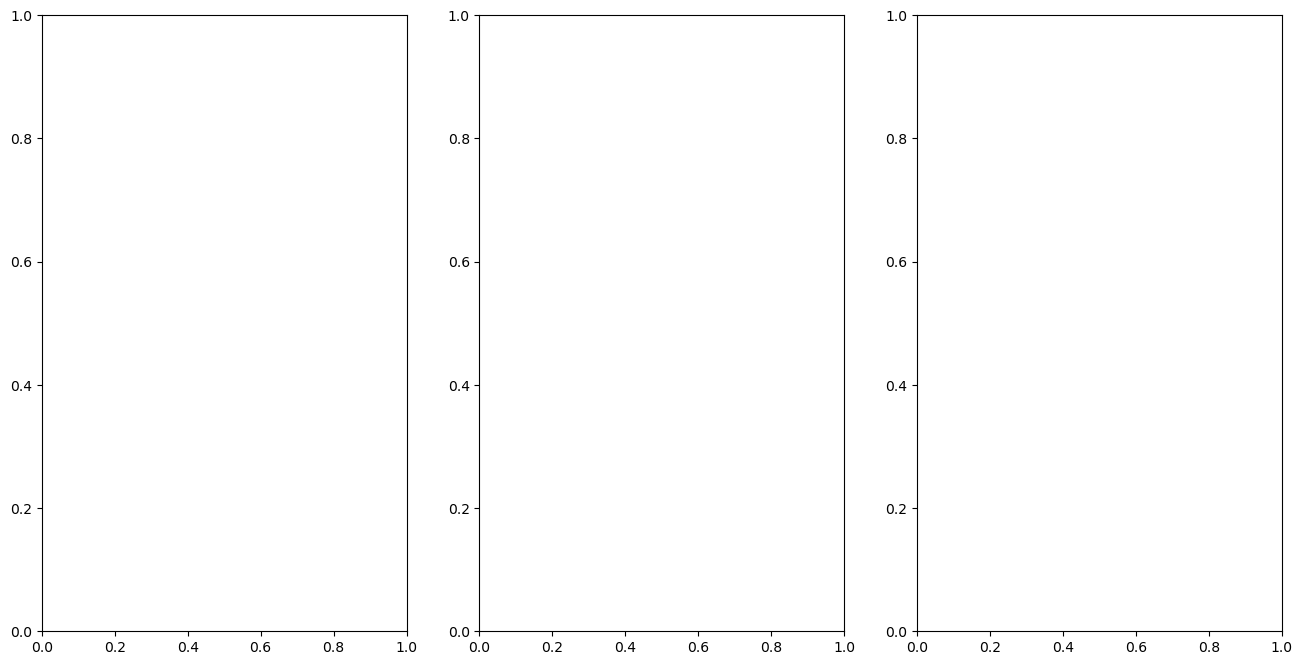

In [ ]:
# plotting UMAPs with specific cell types (use the same code block as the ones I used for the final paper)
methods = integration_method.unique()
attributes = ['batch', 'celltype', 'leiden']

# Create 5x3 plot
fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.flatten()

# Plot each UMAP
for i, method in enumerate(methods):
    if method == "uce":
        adata = adata_c_uce
    elif method == "scgpt":
        adata = adata_c_scgpt
    elif method == "geneformer":
        adata = adata_c_geneformer
    elif method == "harmony":
        adata = adata_c_harmony
    elif method == "scvi":
        adata = adata_c_scvi

    for j, attr in enumerate(attributes):
        idx = i * 3 + j
        sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_kmeans')
        sc.tl.leiden(adata, resolution=1.0)
        sc.tl.umap(adata)
        sc.pl.umap(adata, color=attr, ax=axes[idx], show=False, title=f'{method} - {attr}', legend_loc='none')

plt.tight_layout()
# plt.savefig("control_umap_celltype.png", dpi=300, bbox_inches='tight')
plt.show()

######################################################## hierarchical cell type
# Create 5x3 plot
fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.flatten()

# Plot each UMAP
for i, method in enumerate(methods):
    if method == "uce":
        adata = adata_h_uce
    elif method == "scgpt":
        adata = adata_h_scgpt
    elif method == "geneformer":
        adata = adata_h_geneformer
    elif method == "harmony":
        adata = adata_h_harmony
    elif method == "scvi":
        adata = adata_h_scvi

    for j, attr in enumerate(attributes):
        idx = i * 3 + j
        sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_kmeans')
        sc.tl.leiden(adata, resolution=1.0)
        sc.tl.umap(adata)
        if j == 1:
            sc.pl.umap(adata, color=attr, ax=axes[idx], show=False, title=f'{method} - hierarchical cell type', legend_loc='none')
        else:
            sc.pl.umap(adata, color=attr, ax=axes[idx], show=False, title=f'{method} - {attr}', legend_loc='none')
            
plt.tight_layout()
# plt.savefig("control_umap_hier.png", dpi=300, bbox_inches='tight')
plt.show()


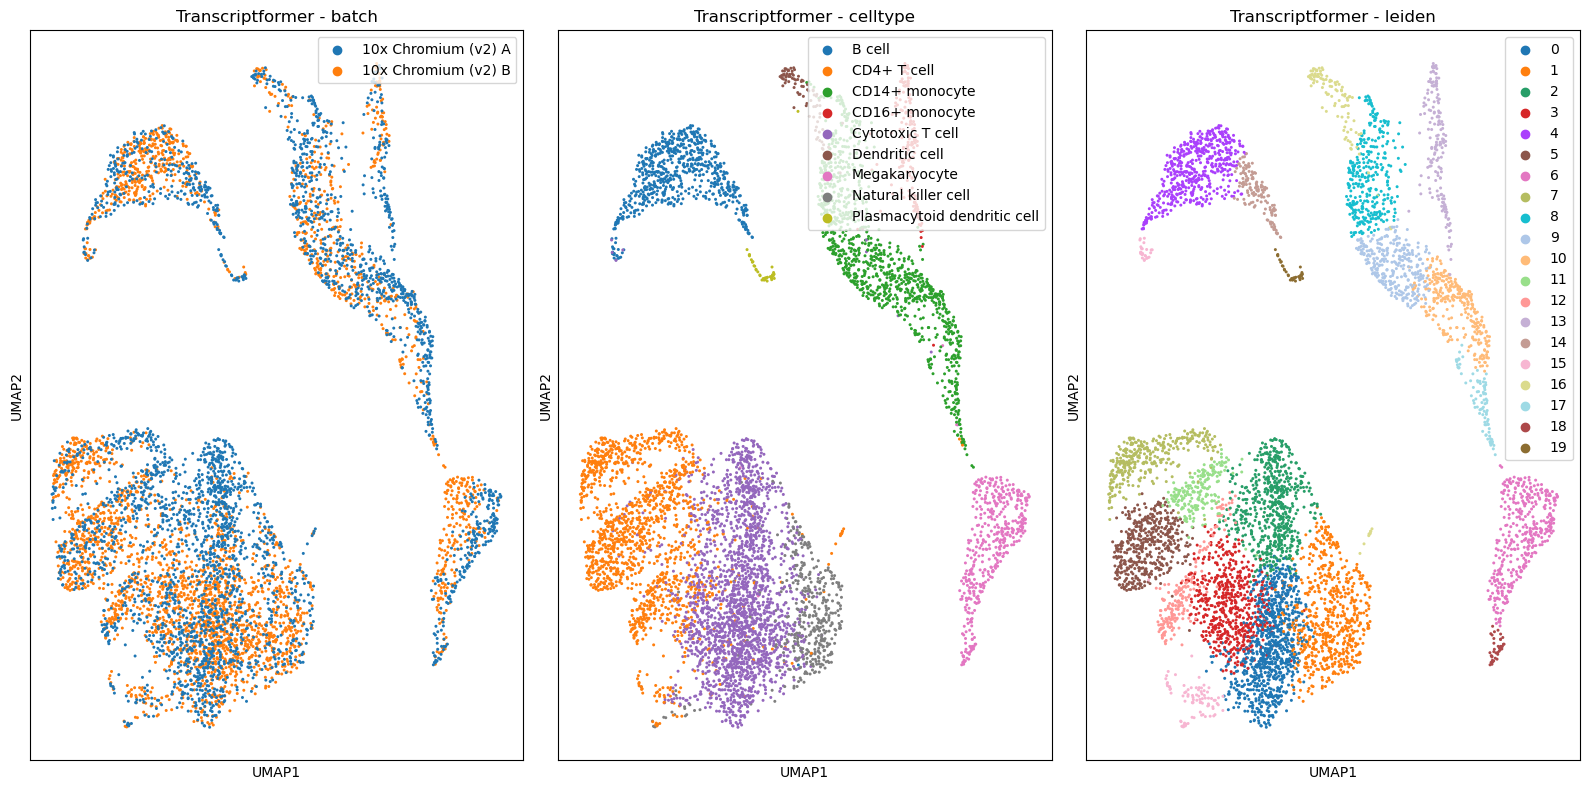

In [14]:
######################################################## transcriptformer
attributes = ['batch', 'celltype', 'leiden']
# Create 5x3 plot
fig, axes = plt.subplots(1, 3, figsize=(16, 8))
axes = axes.flatten()

for j, attr in enumerate(attributes):
    idx = 0 * 3 + j
    sc.pp.neighbors(adata_tsf, n_neighbors=15, use_rep='X_kmeans')
    sc.tl.leiden(adata_tsf, resolution=1.0)
    sc.tl.umap(adata_tsf)
    sc.pl.umap(adata_tsf, color=attr, ax=axes[idx], show=False, title=f'Transcriptformer - {attr}', legend_loc='upper right')

plt.tight_layout()
# plt.savefig("control_umap_celltype_tsf.png", dpi=300, bbox_inches='tight')
plt.show()

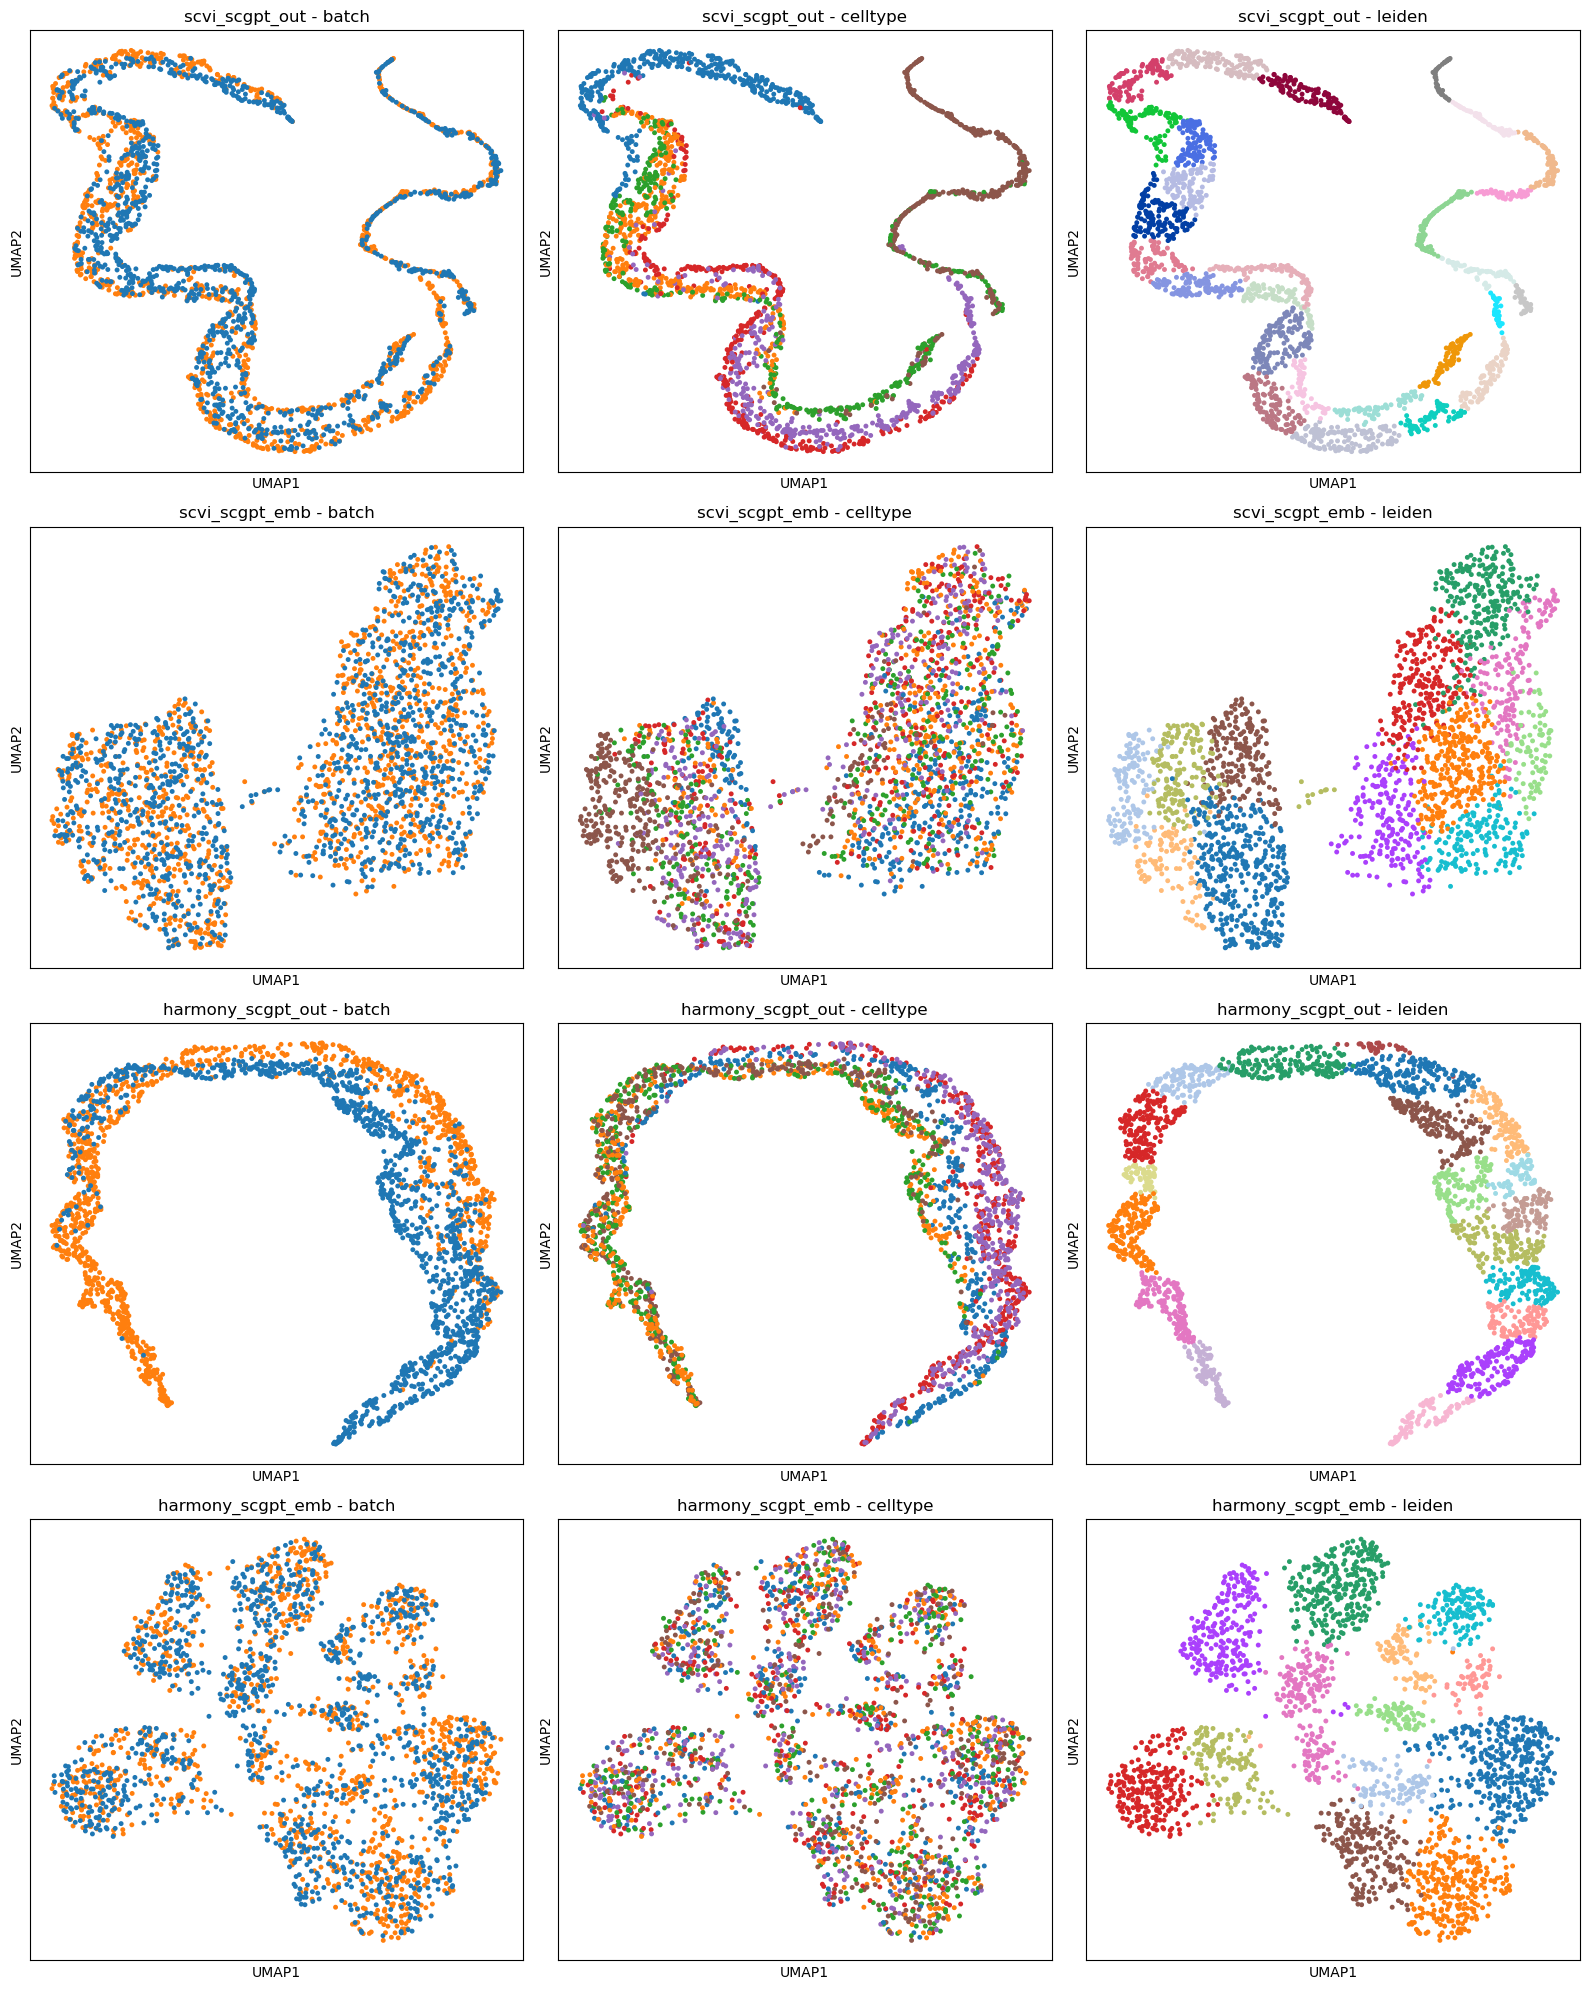

In [13]:
######################################################## finetuned scgpt
# Plot each UMAP
methods_ft = ['scvi_scgpt_out', 'scvi_scgpt_emb', 'harmony_scgpt_out', 'harmony_scgpt_emb']
attributes = ['batch', 'celltype', 'leiden']

fig, axes = plt.subplots(4, 3, figsize=(16, 20))
axes = axes.flatten()

for i, method in enumerate(methods_ft):
    if method == "scvi_scgpt_out":
        adata = scvi_scgpt_out
        adata.obsm['X_kmeans'] = adata.obsm['X_finetuned_output']
    elif method == "scvi_scgpt_emb":
        adata = scvi_scgpt_emb
        adata.obsm['X_kmeans'] = adata.obsm['X_finetuned_emb']
    elif method == "harmony_scgpt_out":
        adata = harmony_scgpt_out
        adata.obsm['X_kmeans'] = adata.obsm['X_finetuned_output']
    elif method == "harmony_scgpt_emb":
        adata = harmony_scgpt_emb
        adata.obsm['X_kmeans'] = adata.obsm['X_finetuned_emb']

    for j, attr in enumerate(attributes):
        idx = i * 3 + j
        sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_kmeans')
        sc.tl.leiden(adata, resolution=1.0)
        sc.tl.umap(adata)
        sc.pl.umap(adata, color=attr, ax=axes[idx], show=False, title=f'{method} - {attr}', legend_loc='none')

plt.tight_layout()
# plt.savefig("control_umap_celltype.png", dpi=300, bbox_inches='tight')
plt.show()